<a href="https://colab.research.google.com/github/champe02/projects/blob/main/BRAIN_MR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [ ]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [ ]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [ ]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


In [ ]:
tr_df = train_df('/kaggle/input/brain-tumor-mri-dataset/Training')

In [ ]:
tr_df

,Class Path,Class
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5595,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5596,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5597,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5598,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [ ]:
ts_df = test_df('/kaggle/input/brain-tumor-mri-dataset/Testing')

In [ ]:
ts_df

,Class Path,Class
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
...,...,...
1595,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1596,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1597,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1598,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma


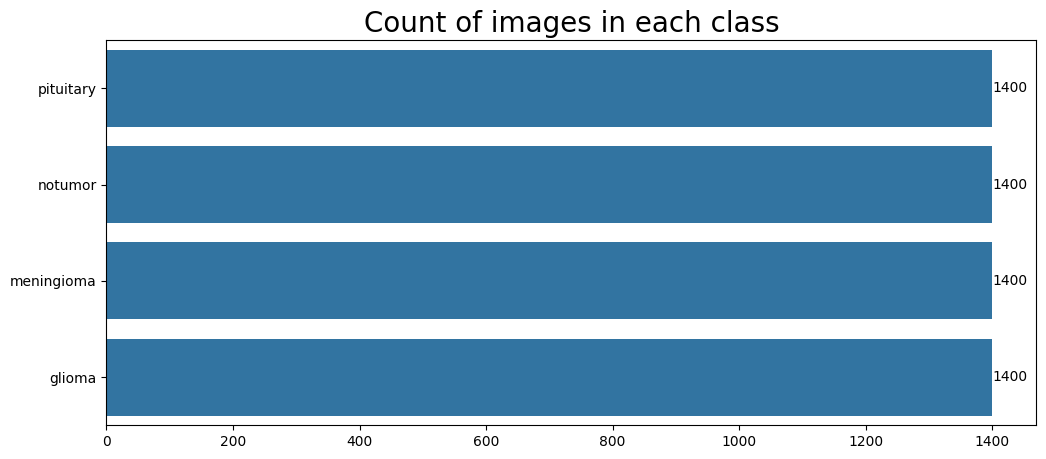

In [ ]:
# Count of images in each class in train data
plt.figure(figsize=(12,5))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

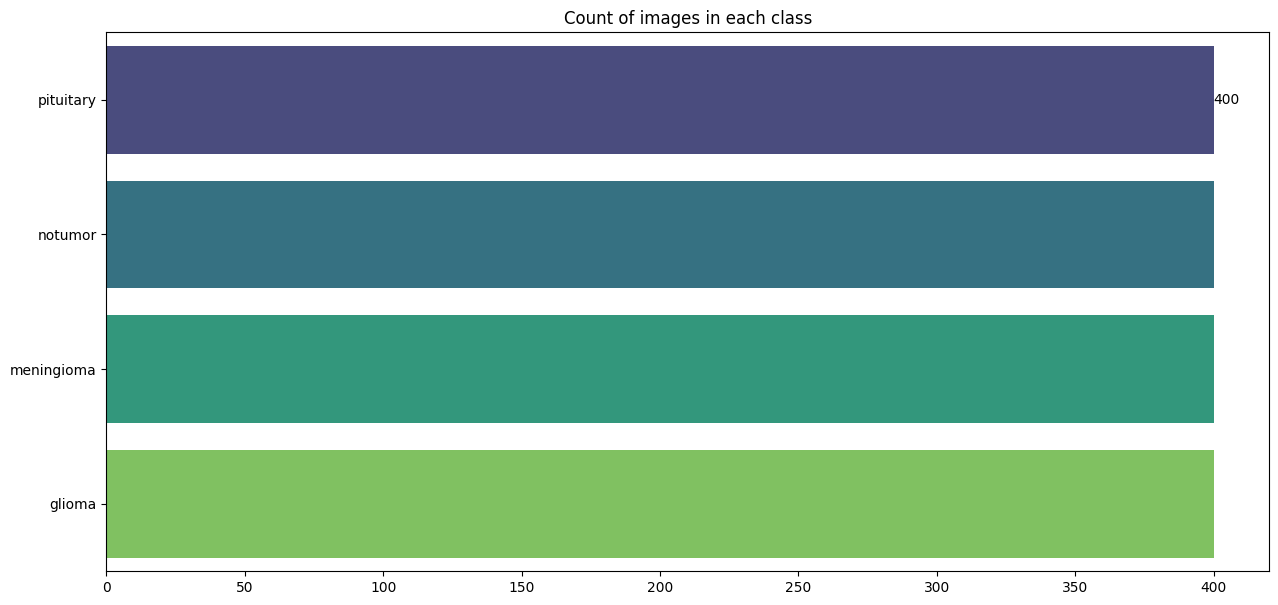

In [ ]:
#Count each class in test data
plt.figure(figsize=(15, 7))
ax = sns.countplot(y=ts_df['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])

plt.show()

In [ ]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

In [ ]:
valid_df

,Class Path,Class
198,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
857,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma
1098,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma
1119,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma
508,/kaggle/input/brain-tumor-mri-dataset/Testing/...,notumor
...,...,...
1281,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
172,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
792,/kaggle/input/brain-tumor-mri-dataset/Testing/...,notumor
933,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma


In [ ]:

batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


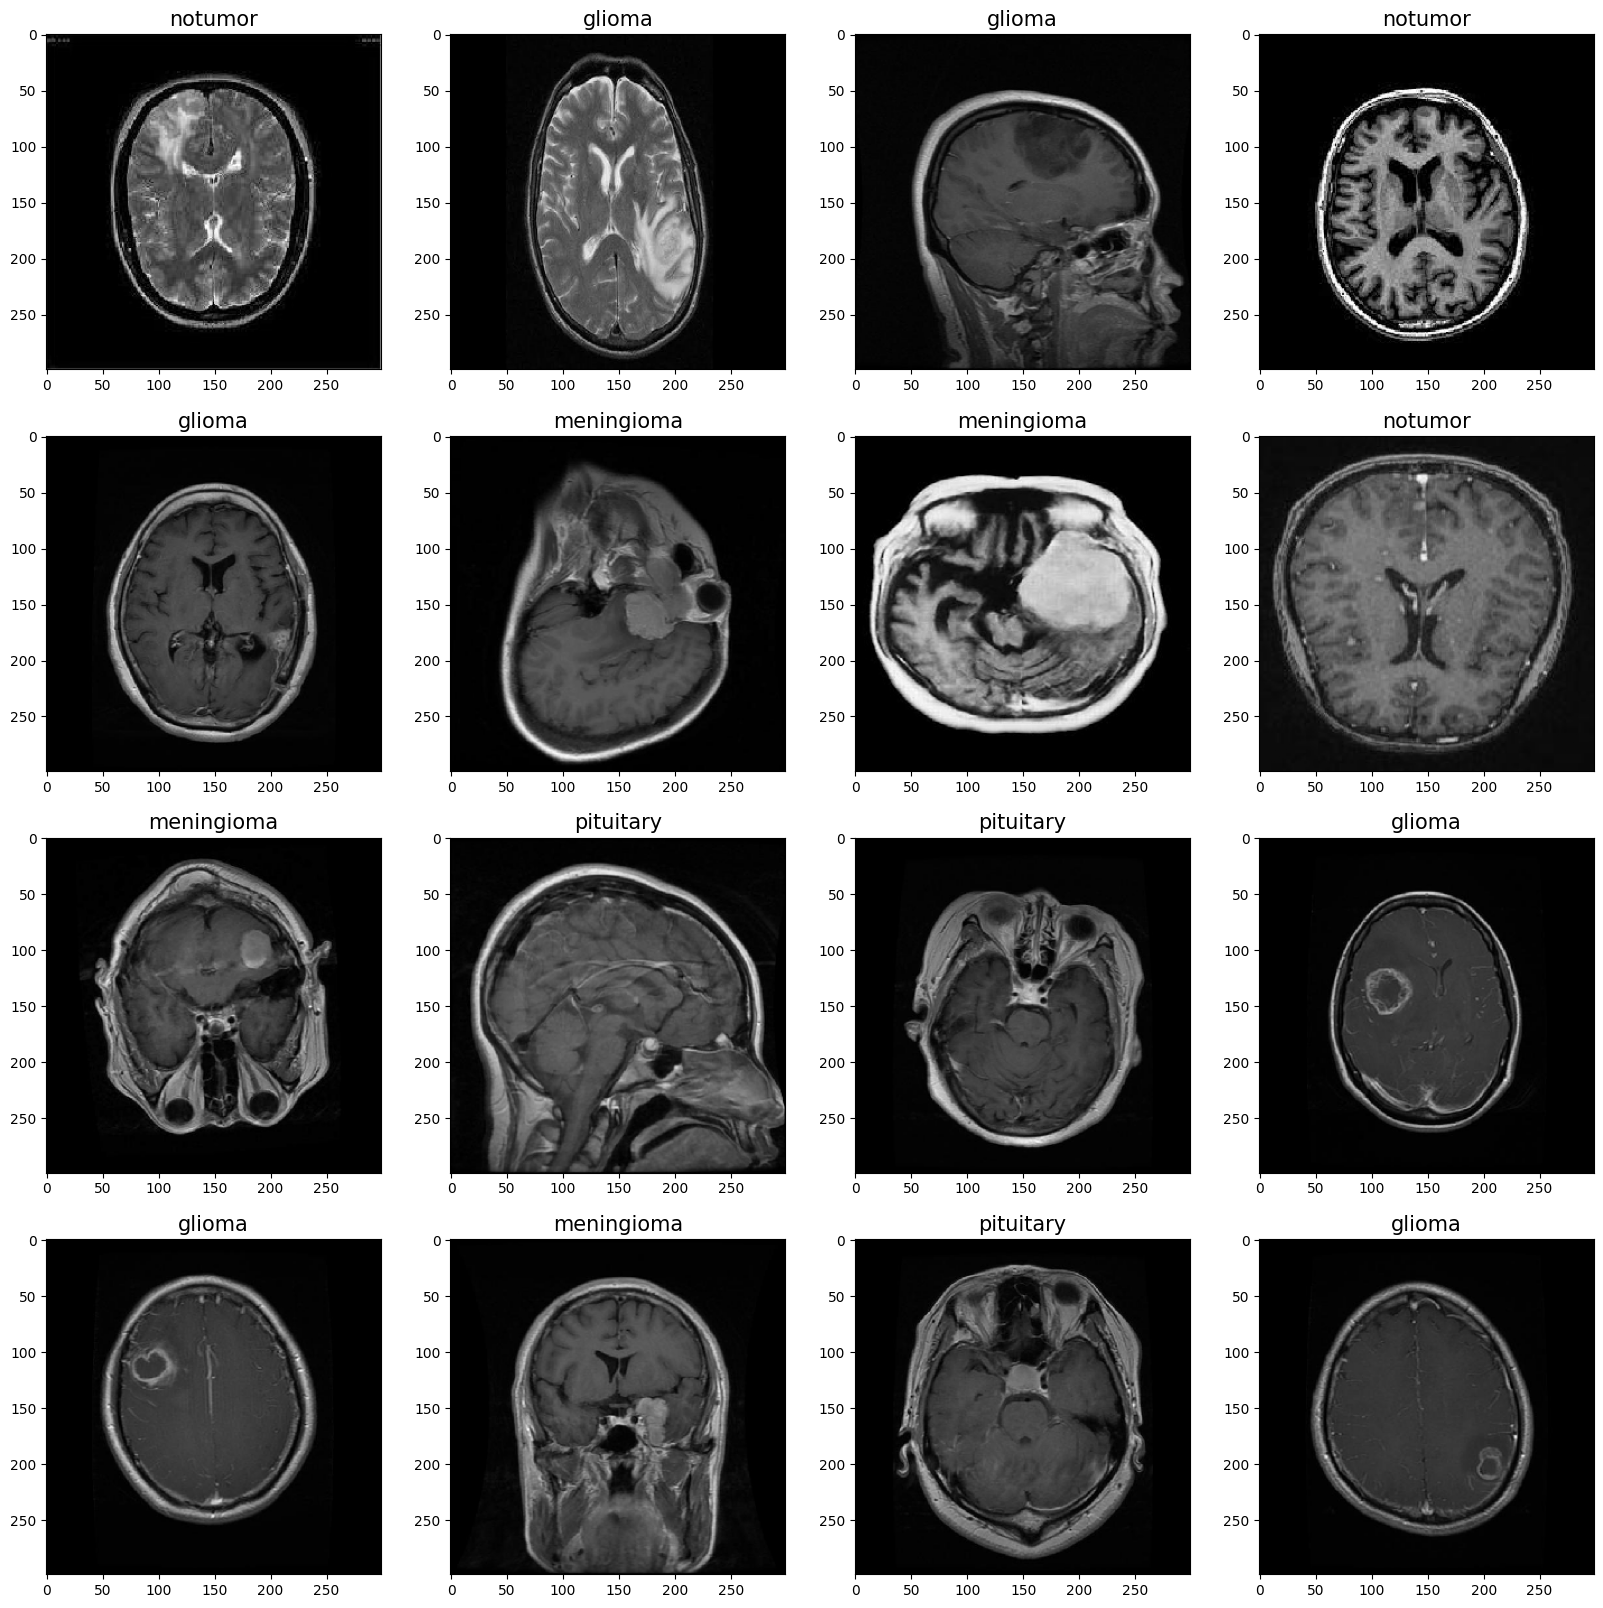

In [ ]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)

plt.show()

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16

In [ ]:
# Load pre-trained base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False # Freeze the base model

# Build model with Batch Normalization
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(), # Required component
    Dropout(0.3),
    Dense(4, activation='softmax')
])

In [ ]:
img_shape=(299,299,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

# for layer in base_model.layers:
#     layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    BatchNormalization(), # Required component
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,780 (80.58 MB)

 Trainable params: 21,069,996 (80.38 MB)

 Non-trainable params: 54,784 (214.00 KB)

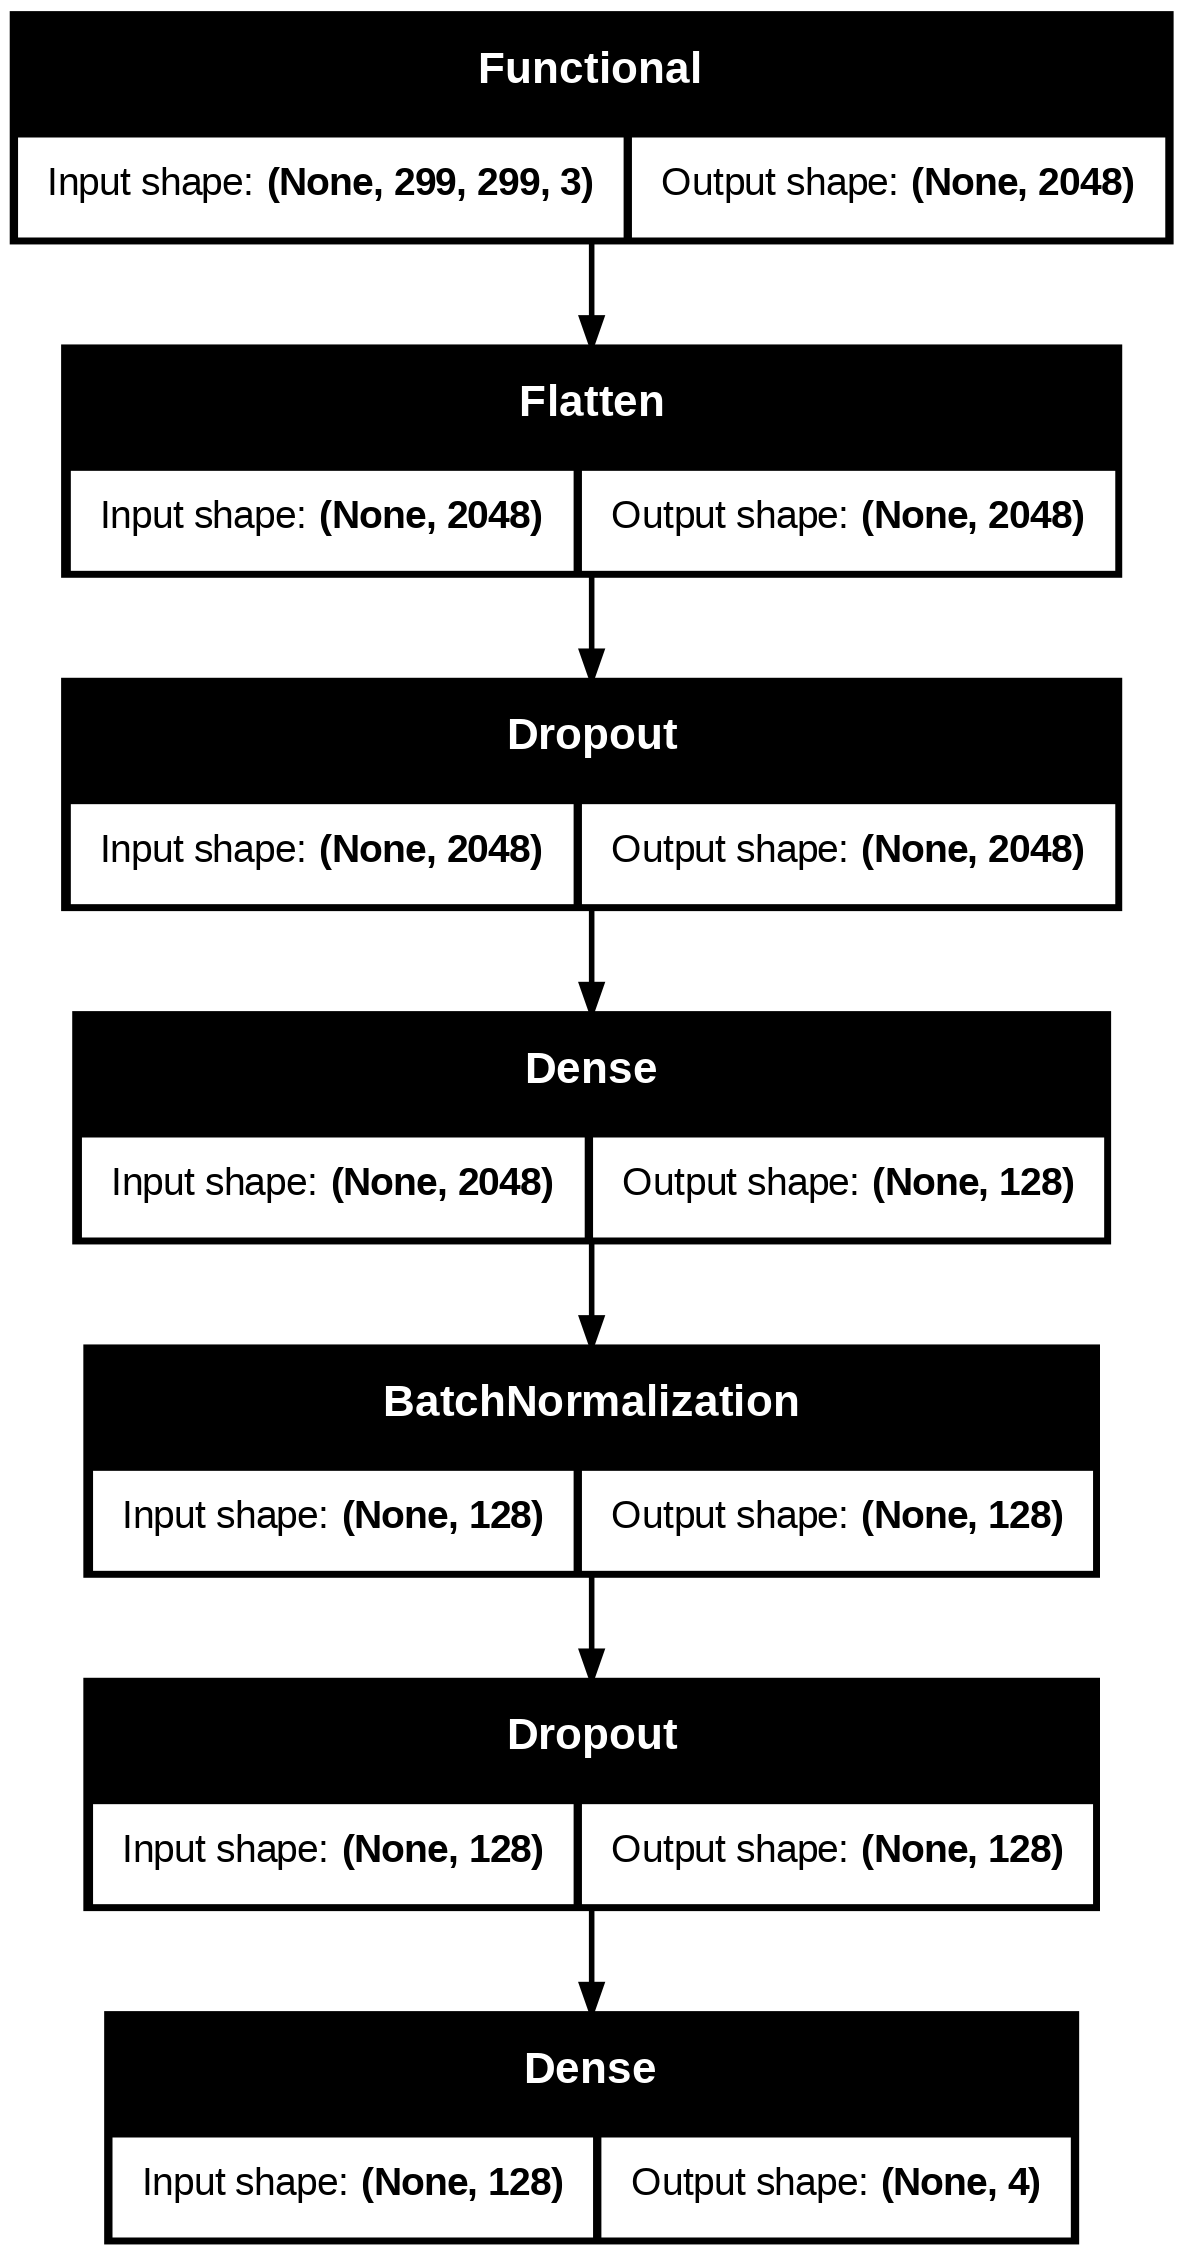

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
hist = model.fit(tr_gen,
                 epochs=10,
                 validation_data=valid_gen,
                 shuffle= False)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.9766 - loss: 0.0724 - precision_1: 0.9785 - recall_1: 0.9732 - val_accuracy: 0.9475 - val_loss: 0.2677 - val_precision_1: 0.9497 - val_recall_1: 0.9450
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9896 - loss: 0.0323 - precision_1: 0.9905 - recall_1: 0.9895 - val_accuracy: 0.9413 - val_loss: 0.3123 - val_precision_1: 0.9424 - val_recall_1: 0.9400
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9957 - loss: 0.0170 - precision_1: 0.9961 - recall_1: 0.9952 - val_accuracy: 0.9513 - val_loss: 0.2705 - val_precision_1: 0.9536 - val_recall_1: 0.9500
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9957 - loss: 0.0136 - precision_1: 0.9959 - recall_1: 0.9957 - val_accuracy: 0.9375 - val_loss: 0.3596 - val_precision_1: 0.9398 - val_recall_1: 0.9375
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9980 - loss: 0.0102 - precision_1: 0.9980 - recall_1: 0.9

In [ ]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision_1', 'recall_1', 'val_accuracy', 'val_loss', 'val_precision_1', 'val_recall_1'])

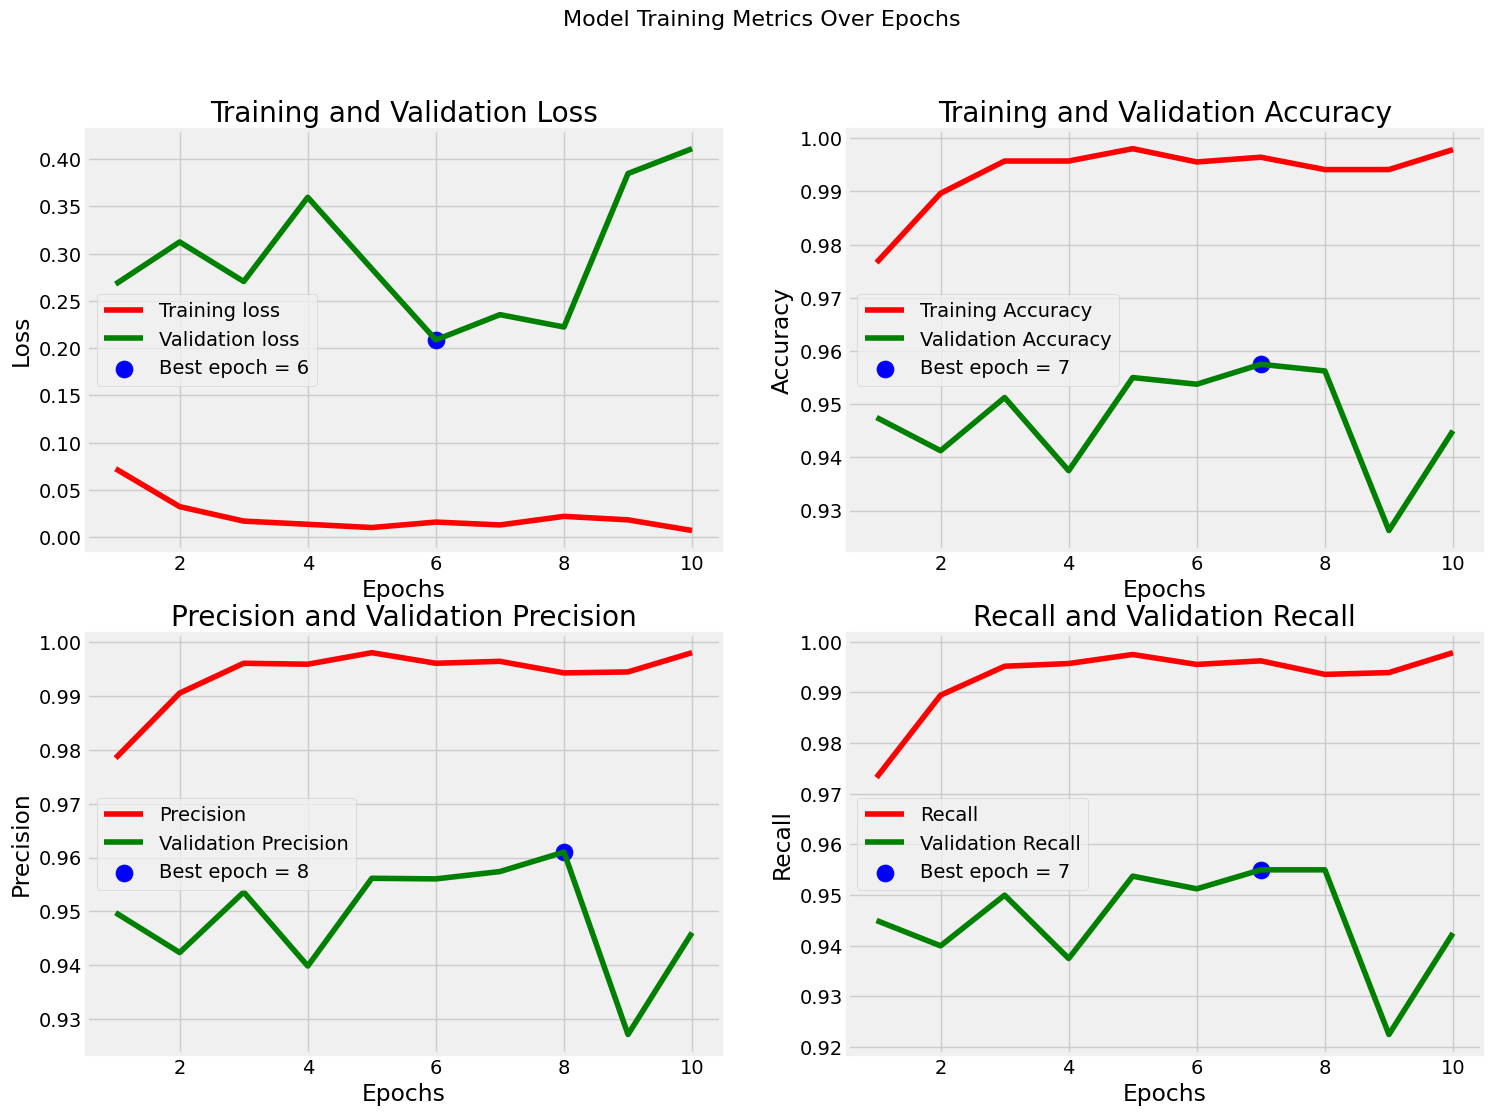

In [ ]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision_1']
tr_recall = hist.history['recall_1']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision_1']
val_recall = hist.history['val_recall_1']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'


plt.figure(figsize=(18, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()

In [ ]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

175/175 ━━━━━━━━━━━━━━━━━━━━ 58s 329ms/step - accuracy: 0.9991 - loss: 0.0036 - precision_1: 0.9991 - recall_1: 0.9989
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.9450 - loss: 0.3099 - precision_1: 0.9450 - recall_1: 0.9450
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 155ms/step - accuracy: 0.9500 - loss: 0.3537 - precision_1: 0.9500 - recall_1: 0.9500
Train Loss: 0.0036
Train Accuracy: 99.91%
--------------------
Validation Loss: 0.3099
Validation Accuracy: 94.50%
--------------------
Test Loss: 0.3537
Test Accuracy: 95.00%


In [ ]:
preds = model.predict(ts_gen)
y_pred = np.argmax(preds, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 145ms/step


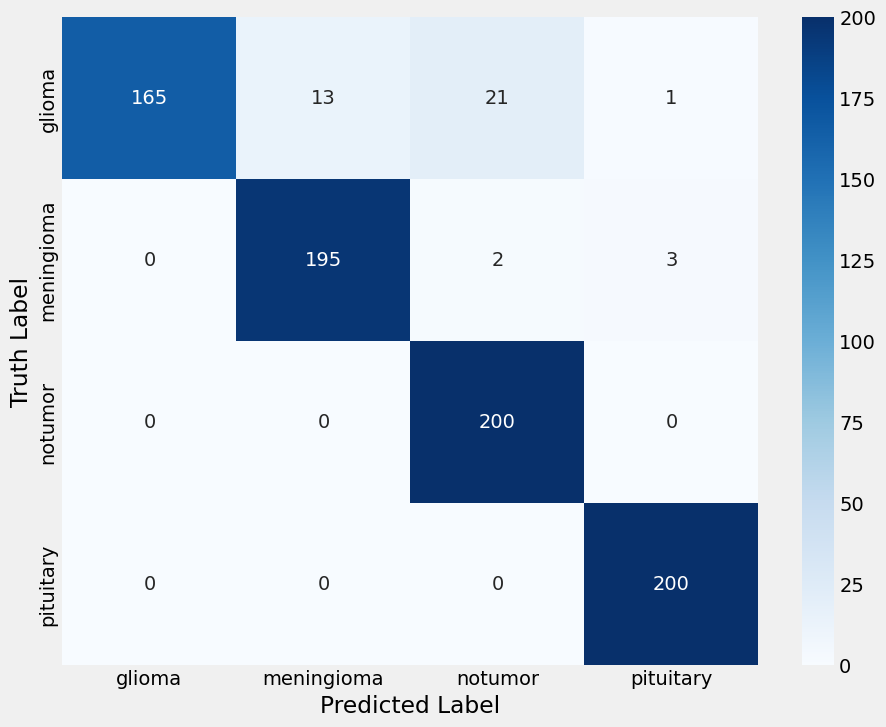

In [ ]:
cm = confusion_matrix(ts_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

In [ ]:
clr = classification_report(ts_gen.classes, y_pred)
print(clr)

              precision    recall  f1-score   support

           0       1.00      0.82      0.90       200
           1       0.94      0.97      0.96       200
           2       0.90      1.00      0.95       200
           3       0.98      1.00      0.99       200

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



In [ ]:
def predict(img_path):
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image
    label = list(class_dict.keys())
    plt.figure(figsize=(12, 12))
    img = Image.open(img_path)
    resized_img = img.resize((299, 299))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = model.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step


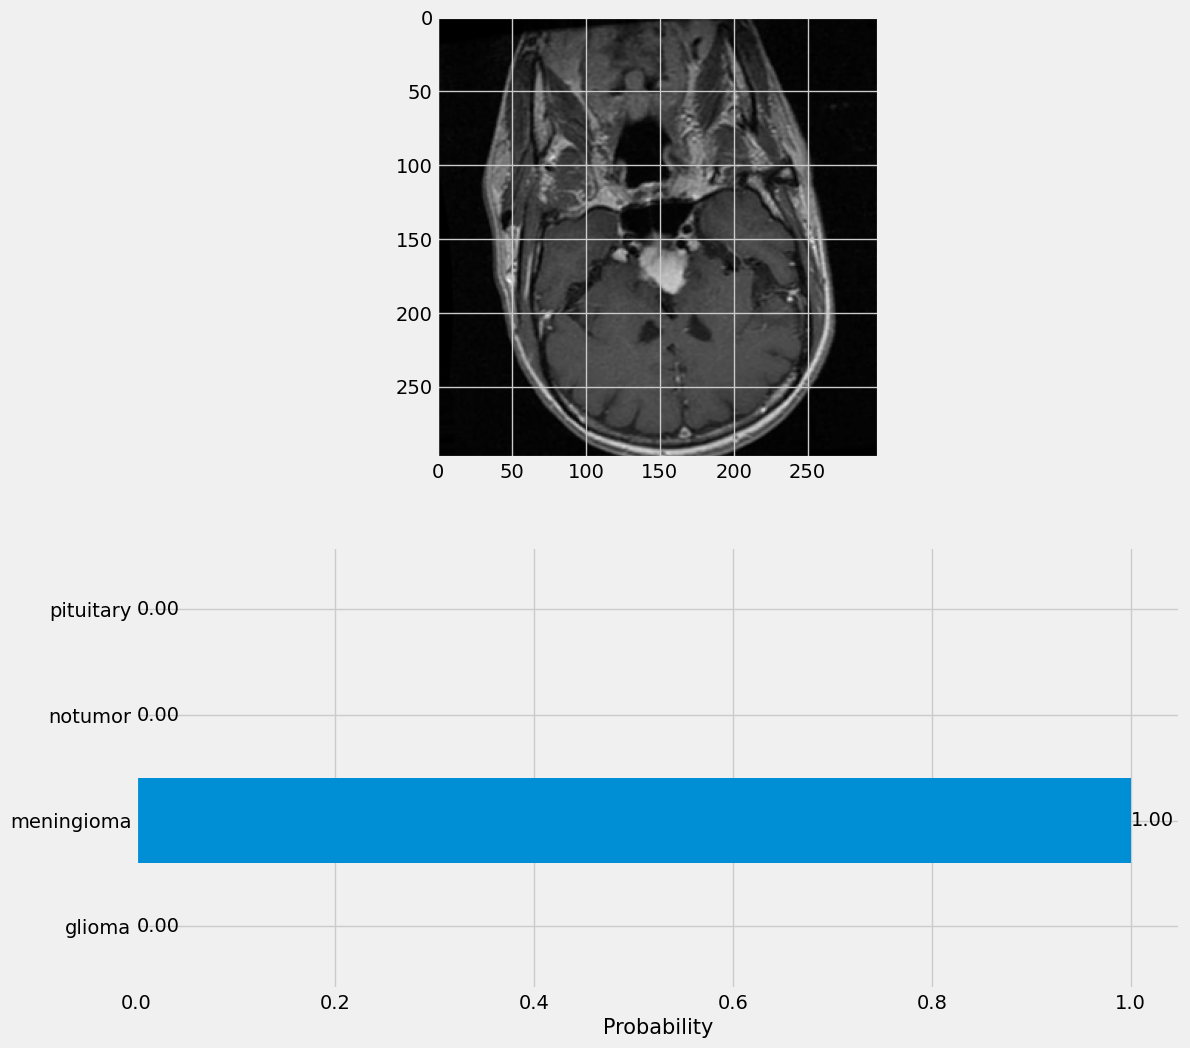

In [ ]:
predict('/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-aug-me_10.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


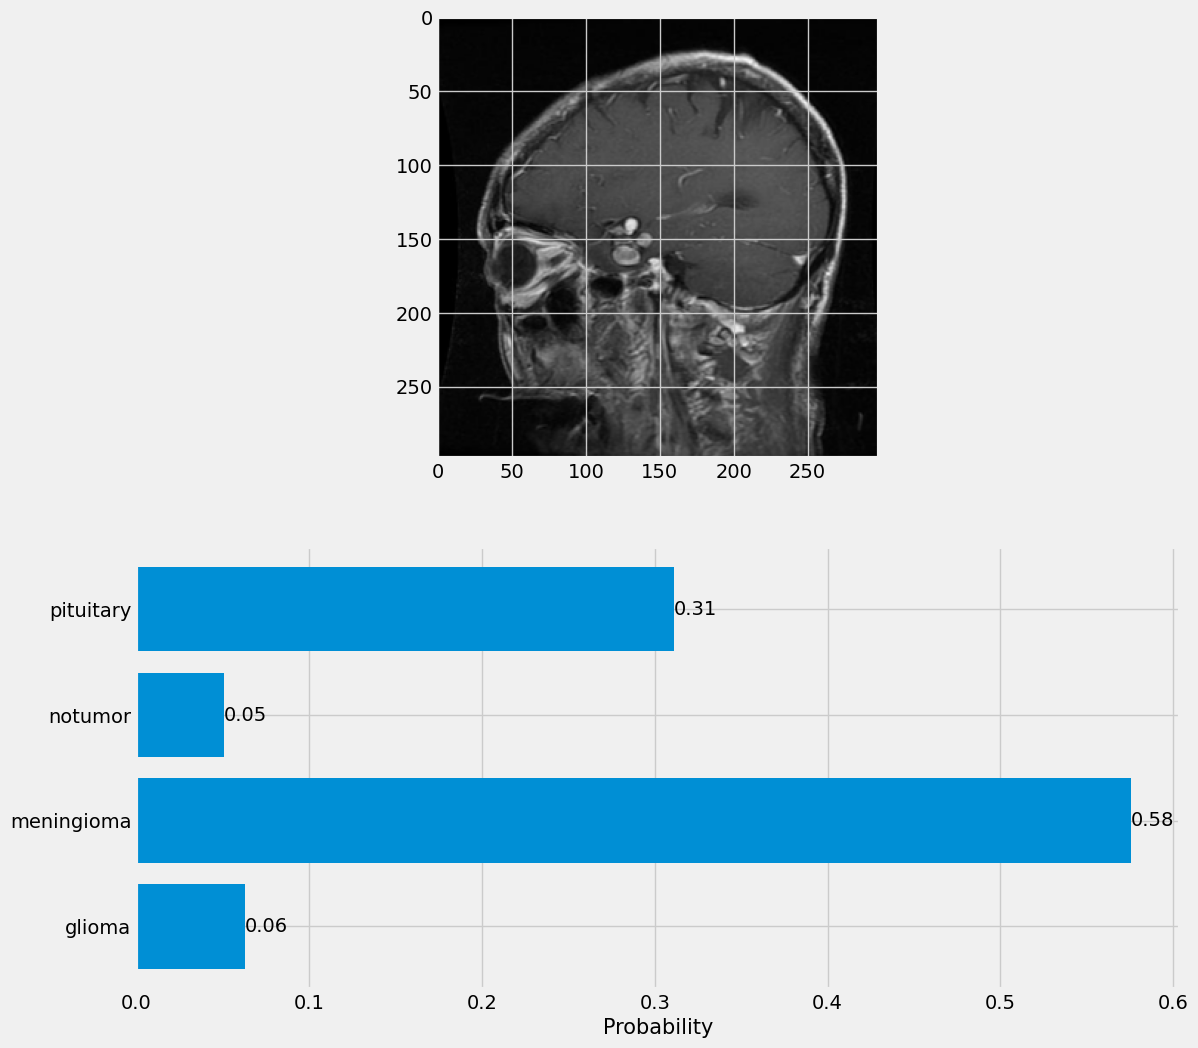

In [ ]:
predict('/kaggle/input/brain-tumor-mri-dataset/Testing/glioma/Te-gl_108.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


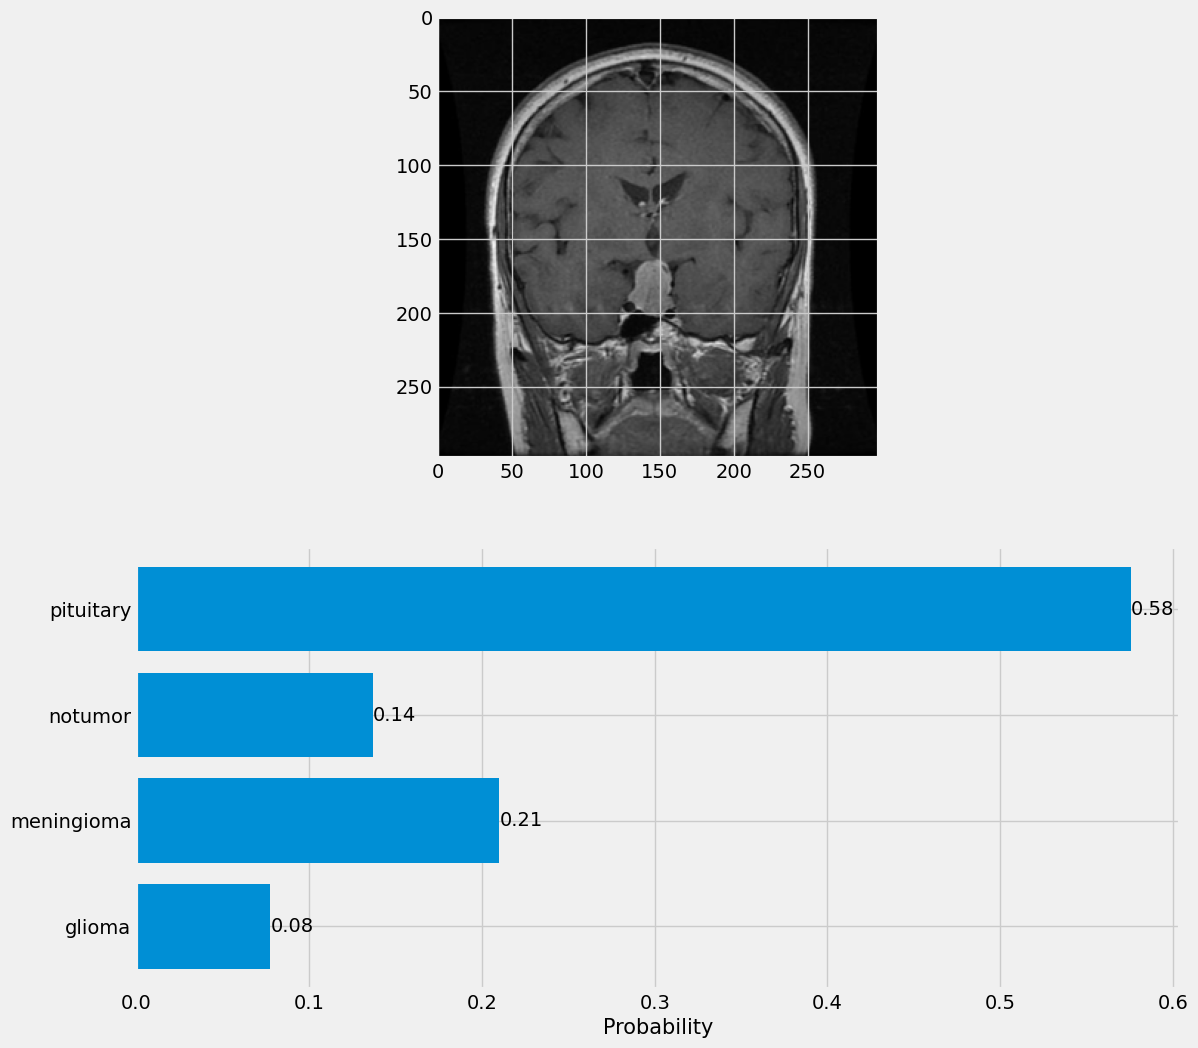

In [ ]:
predict('/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary/Te-pi_101.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


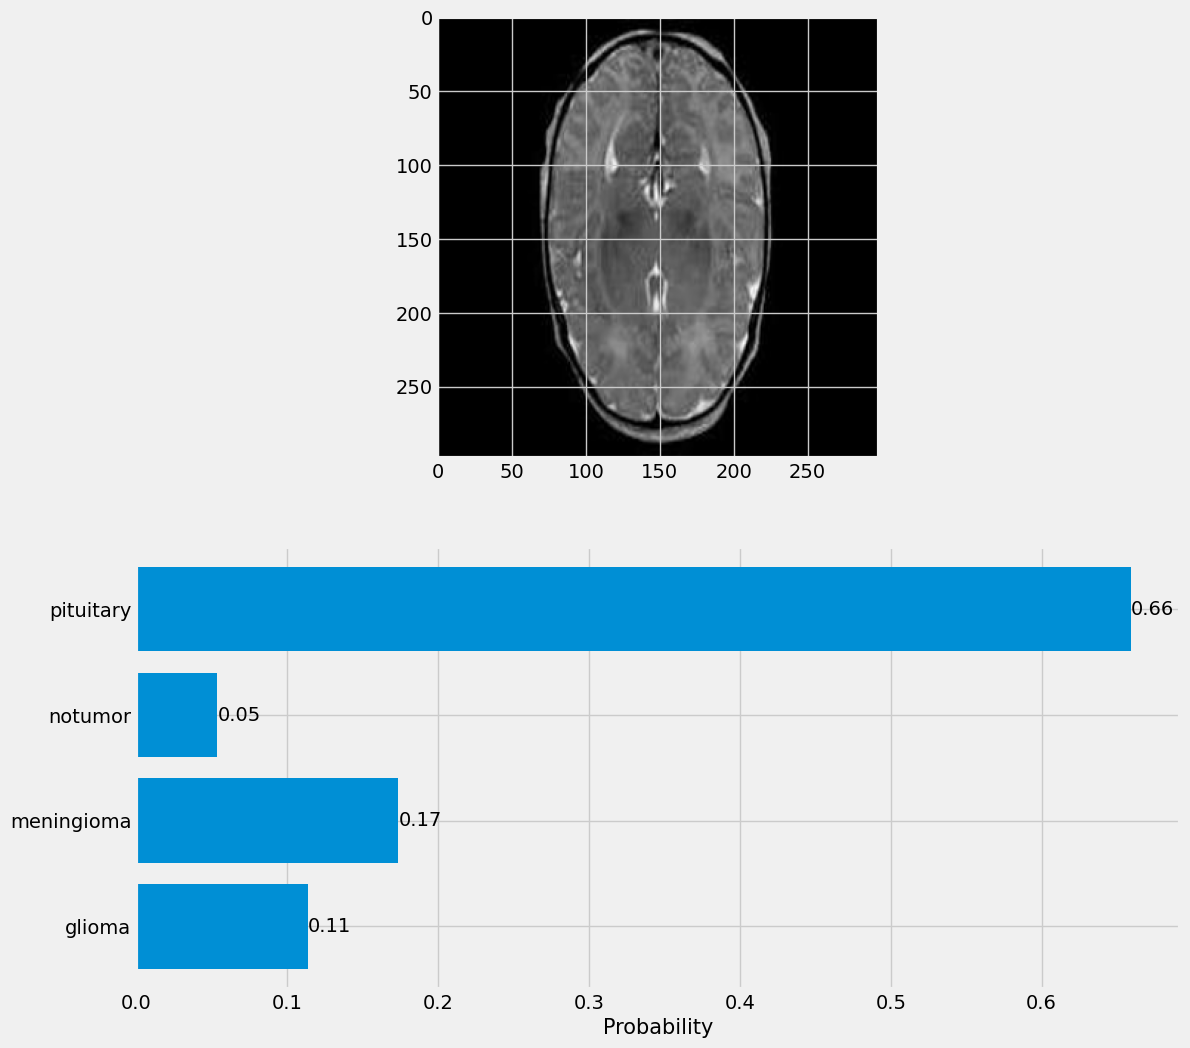

In [ ]:
predict('/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-no_103.jpg')

In [ ]:
# Save the model in the modern Keras format (or .h5)
model.save('brain_tumor_classifier.h5')

print("Model successfully saved as brain_tumor_classifier.h5")

Model successfully saved as brain_tumor_classifier.h5


In [ ]:
import tensorflow as tf

# Convert the saved Keras model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted model to a file
with open('brain_tumor_classifier.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model successfully converted and saved as brain_tumor_classifier.tflite")

Saved artifact at '/tmp/tmpe0wfv2ng'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='keras_tensor_506')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138746594912848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138746594903440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138746594909392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138746594910928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138746594908624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138746594902864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138746594910160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138746594907856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138746594910736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138746594909968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1387465949